# 01 Exploratory Data Analysis

Explore market returns, risk, missing sessions, correlations, and volatility before modeling. All return calculations are isolated by ticker so one stock never uses another stock's previous price.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import seaborn as sns

warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

In [2]:
df = pd.read_csv(DATA_DIR / "sp500_stocks.csv", parse_dates=["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
print(f"Rows: {len(df):,} | Tickers: {df['Ticker'].nunique()}")
print(f"Dates: {df['Date'].min().date()} to {df['Date'].max().date()}")
display(df.head())

Rows: 259,073 | Tickers: 50
Dates: 2005-01-03 to 2025-12-30


,Date,Close,High,Low,Open,Volume,Ticker
0,2005-01-03,0.946491,0.973708,0.936171,0.968773,691992000,AAPL
1,2005-01-04,0.956211,0.979092,0.941705,0.953968,1096810400,AAPL
2,2005-01-05,0.964586,0.975802,0.957856,0.963987,680433600,AAPL
3,2005-01-06,0.965334,0.970717,0.947089,0.967128,705555200,AAPL
4,2005-01-07,1.035620,1.041304,0.968324,0.972062,2227450400,AAPL


## Daily log returns

Log returns add across time and map price relatives onto a symmetric scale. The backtest converts their cumulative sum back to a simple portfolio return with `exp(sum(log_returns)) - 1`.

In [3]:
df["LogReturn"] = df.groupby("Ticker")["Close"].transform(
    lambda prices: np.log(prices / prices.shift(1))
)
display(df[["Date", "Ticker", "Close", "LogReturn"]].head())

,Date,Ticker,Close,LogReturn
0,2005-01-03,AAPL,0.946491,NaN
1,2005-01-04,AAPL,0.956211,0.010218
2,2005-01-05,AAPL,0.964586,0.008720
3,2005-01-06,AAPL,0.965334,0.000775
4,2005-01-07,AAPL,1.035620,0.070282


## Missing-session audit

In [4]:
nyse = mcal.get_calendar("NYSE")
overall_end = df["Date"].max()


def audit_ticker(group):
    start, end = group["Date"].min(), group["Date"].max()
    expected = nyse.schedule(start, end).index.normalize()
    observed = pd.DatetimeIndex(group["Date"]).normalize()
    missing = expected.difference(observed)
    return pd.Series({
        "first_date": start,
        "last_date": end,
        "missing_sessions": len(missing),
        "missing_pct": 100 * len(missing) / max(len(expected), 1),
        "ends_early": end < overall_end - pd.Timedelta(days=10),
    })


missing_report = df.groupby("Ticker").apply(audit_ticker, include_groups=False)
display(missing_report.sort_values("missing_sessions", ascending=False).head(10))

,first_date,last_date,missing_sessions,missing_pct,ends_early
Ticker,,,,,
AAPL,2005-01-03,2025-12-30,0,0.0,False
ABBV,2013-01-02,2025-12-30,0,0.0,False
AMT,2005-01-03,2025-12-30,0,0.0,False
AMZN,2005-01-03,2025-12-30,0,0.0,False
APD,2005-01-03,2025-12-30,0,0.0,False
AVGO,2009-08-06,2025-12-30,0,0.0,False
AXP,2005-01-03,2025-12-30,0,0.0,False
BA,2005-01-03,2025-12-30,0,0.0,False
BAC,2005-01-03,2025-12-30,0,0.0,False


Do not create weekend or holiday rows. Investigate long gaps, exclude incomplete feature windows, and never backfill prices from the future.

## Risk and return summary

In [5]:
def stock_statistics(group):
    returns = group["LogReturn"].dropna()
    annual_log_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)
    equity = np.exp(returns.cumsum())
    drawdown = equity / equity.cummax() - 1
    return pd.Series({
        "annualized_return": np.exp(annual_log_return) - 1,
        "annualized_volatility": annual_volatility,
        "sharpe_ratio": annual_log_return / annual_volatility,
        "max_drawdown": drawdown.min(),
    })


stats = df.groupby("Ticker").apply(stock_statistics, include_groups=False)
display(stats.sort_values("sharpe_ratio", ascending=False).head(10))
display(stats.sort_values("sharpe_ratio").head(10))

,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown
Ticker,,,,
AVGO,0.418851,0.377908,0.925749,-0.483000
AAPL,0.310204,0.321588,0.840152,-0.608667
COST,0.170017,0.223751,0.701755,-0.480380
ABBV,0.203046,0.264761,0.698203,-0.450898
NVDA,0.393115,0.486779,0.681094,-0.850784
MCD,0.145155,0.199790,0.678413,-0.368986
GOOGL,0.217985,0.299983,0.657363,-0.652948
LLY,0.185325,0.260591,0.652426,-0.509273
QQQ,0.149042,0.216542,0.641577,-0.534040


,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown
Ticker,,,,
C,-0.043749,0.481601,-0.092888,-0.980002
BAC,0.031231,0.455480,0.067519,-0.934457
SLB,0.029924,0.386374,0.076312,-0.876399
GE,0.053210,0.328628,0.157753,-0.826994
UPS,0.039947,0.247831,0.158051,-0.579177
PFE,0.042723,0.233664,0.179040,-0.589620
MS,0.089655,0.452092,0.189919,-0.870945
WFC,0.084166,0.394023,0.205093,-0.790134
PLD,0.092552,0.405910,0.218068,-0.846972


## Market visualizations

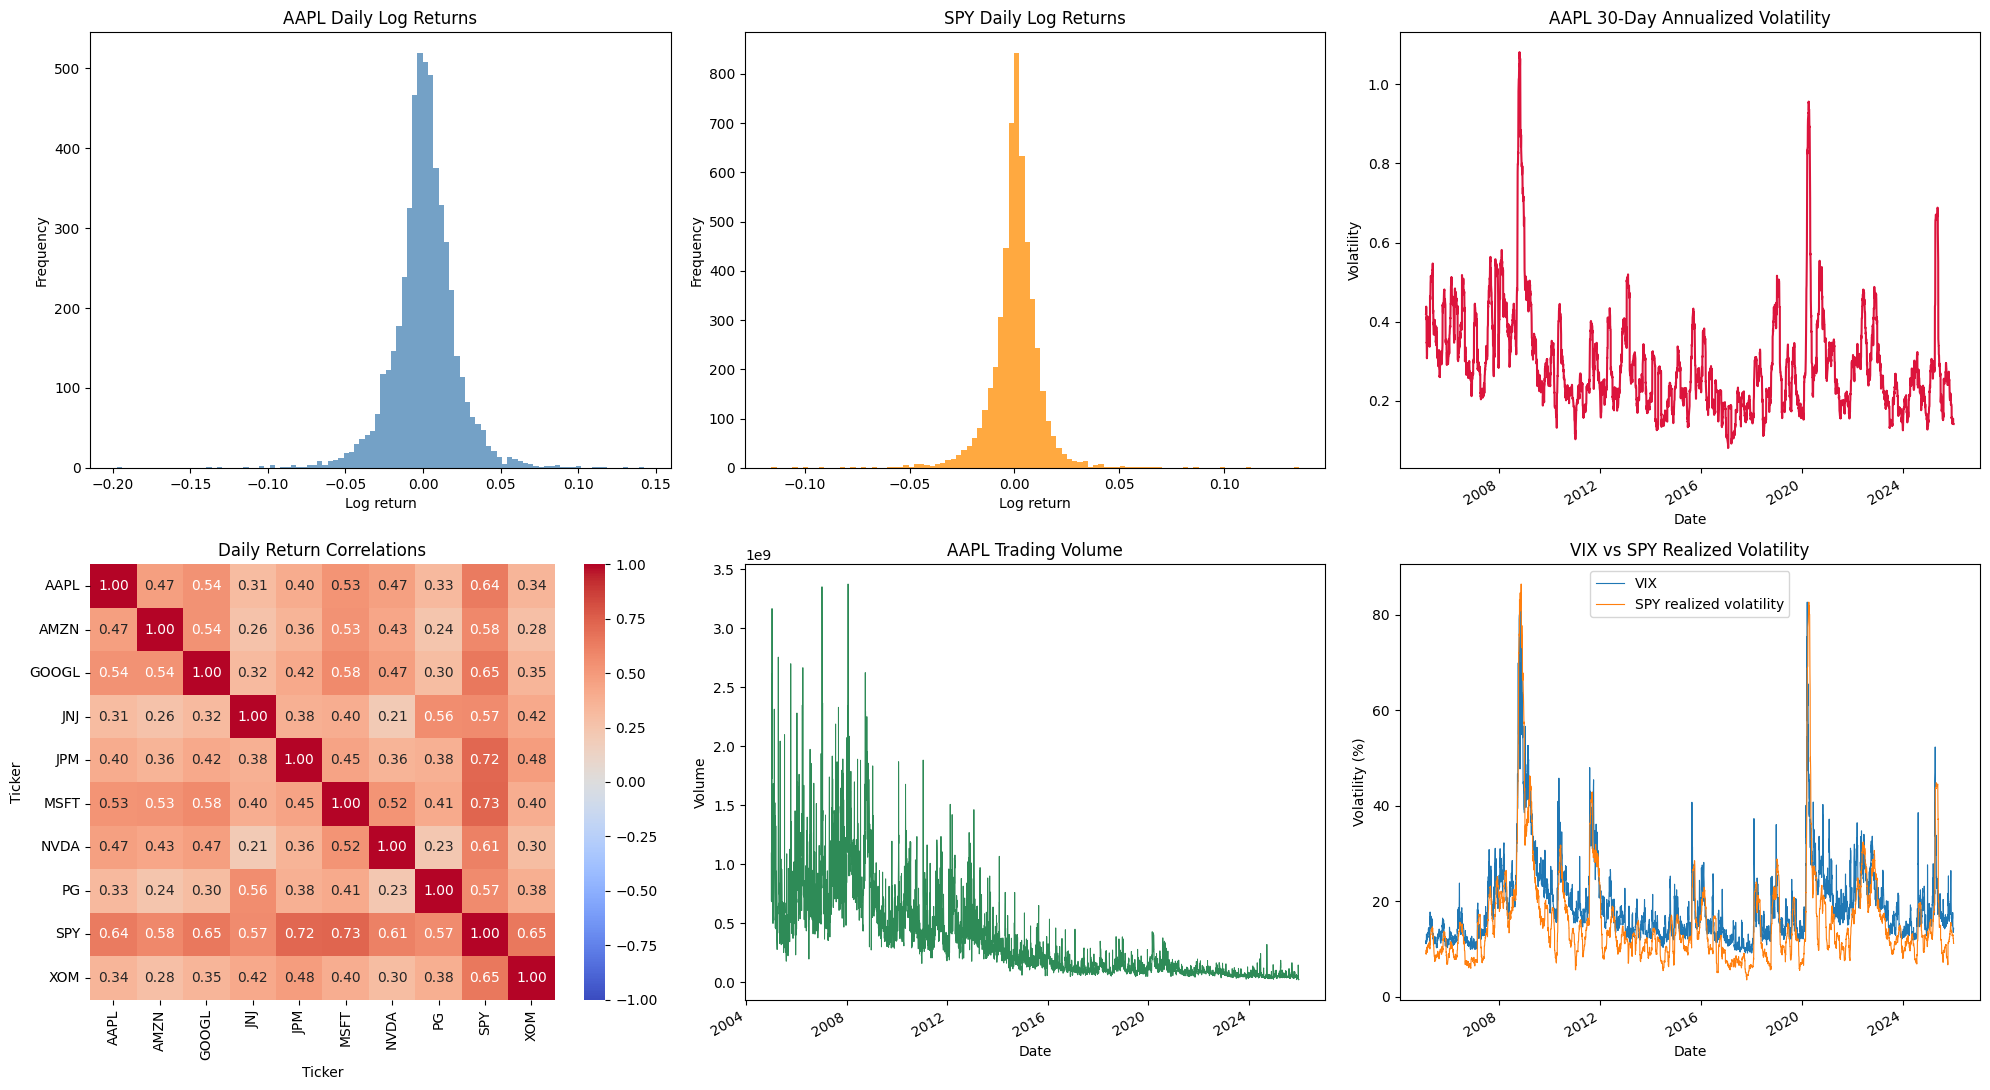

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
aapl_returns = df.loc[df["Ticker"] == "AAPL", "LogReturn"].dropna()
spy_returns = df.loc[df["Ticker"] == "SPY", "LogReturn"].dropna()
axes[0, 0].hist(aapl_returns, bins=100, color="steelblue", alpha=0.75)
axes[0, 0].set(title="AAPL Daily Log Returns", xlabel="Log return", ylabel="Frequency")
axes[0, 1].hist(spy_returns, bins=100, color="darkorange", alpha=0.75)
axes[0, 1].set(title="SPY Daily Log Returns", xlabel="Log return", ylabel="Frequency")

aapl = df[df["Ticker"] == "AAPL"].set_index("Date")
aapl["LogReturn"].rolling(30).std().mul(np.sqrt(252)).plot(ax=axes[0, 2], color="crimson")
axes[0, 2].set(title="AAPL 30-Day Annualized Volatility", xlabel="Date", ylabel="Volatility")

selected = [t for t in ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "JPM", "JNJ", "XOM", "PG", "SPY"] if t in set(df["Ticker"])]
pivot = df[df["Ticker"].isin(selected)].pivot(index="Date", columns="Ticker", values="LogReturn")
sns.heatmap(pivot.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1, 0], vmin=-1, vmax=1)
axes[1, 0].set_title("Daily Return Correlations")

aapl["Volume"].plot(ax=axes[1, 1], color="seagreen", linewidth=0.7)
axes[1, 1].set(title="AAPL Trading Volume", xlabel="Date", ylabel="Volume")

vix = pd.read_csv(DATA_DIR / "vix.csv", parse_dates=["Date"]).set_index("Date")["Close"].rename("VIX")
spy = df[df["Ticker"] == "SPY"].set_index("Date")
realized = spy["LogReturn"].rolling(30).std().mul(np.sqrt(252) * 100).rename("SPY realized volatility")
volatility = pd.concat([vix, realized], axis=1).dropna()
volatility.plot(ax=axes[1, 2], linewidth=0.8)
axes[1, 2].set(title="VIX vs SPY Realized Volatility", xlabel="Date", ylabel="Volatility (%)")
plt.tight_layout()
plt.show()

## Correlation during stressed markets and forward volatility

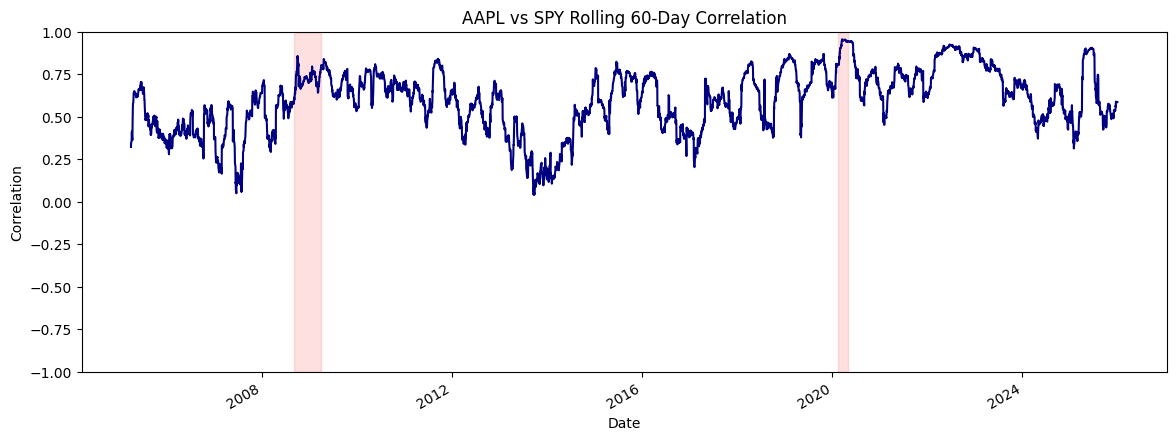

VIX vs current realized volatility: 0.869
VIX vs next 30 trading days' realized volatility: 0.666
Correlation is descriptive, not proof that VIX alone is a profitable forecast.


In [7]:
pair = df[df["Ticker"].isin(["AAPL", "SPY"])].pivot(index="Date", columns="Ticker", values="LogReturn")
rolling_corr = pair["AAPL"].rolling(60).corr(pair["SPY"])
ax = rolling_corr.plot(figsize=(14, 5), color="navy", title="AAPL vs SPY Rolling 60-Day Correlation")
ax.axvspan(pd.Timestamp("2008-09-01"), pd.Timestamp("2009-03-31"), color="red", alpha=0.12)
ax.axvspan(pd.Timestamp("2020-02-15"), pd.Timestamp("2020-04-30"), color="red", alpha=0.12)
ax.set(xlabel="Date", ylabel="Correlation", ylim=(-1, 1))
plt.show()

volatility["future_30d_realized"] = realized.shift(-30)
print(f"VIX vs current realized volatility: {volatility['VIX'].corr(volatility['SPY realized volatility']):.3f}")
print(f"VIX vs next 30 trading days' realized volatility: {volatility['VIX'].corr(volatility['future_30d_realized']):.3f}")
print("Correlation is descriptive, not proof that VIX alone is a profitable forecast.")